In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from pathlib import Path

c:\Users\shett\OneDrive\Documents\supply chain analytics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
RAW = Path("../data/raw")
orders = pd.read_csv(RAW / "orders.csv", parse_dates=["order_date"])

In [3]:
sku_focus = "SKU0001"     # you can change this for other SKUs
df_sku = (
    orders[orders["sku_id"] == sku_focus]
    .groupby("order_date")
    .agg({"qty_ordered": "sum"})
    .reset_index()
)
df_sku.rename(columns={"order_date": "ds", "qty_ordered": "y"}, inplace=True)

In [4]:
model = Prophet(daily_seasonality=True, yearly_seasonality=False)
model.fit(df_sku)

12:21:23 - cmdstanpy - INFO - Chain [1] start processing
12:21:25 - cmdstanpy - INFO - Chain [1] done processing


In [5]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

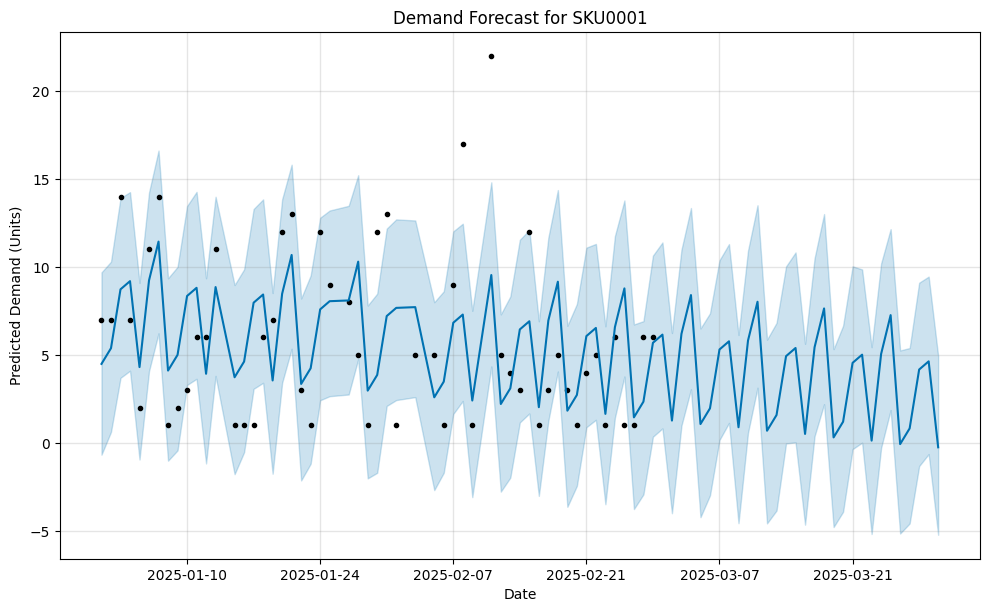

In [6]:
fig1 = model.plot(forecast)
plt.title(f"Demand Forecast for {sku_focus}")
plt.xlabel("Date")
plt.ylabel("Predicted Demand (Units)")
plt.show()

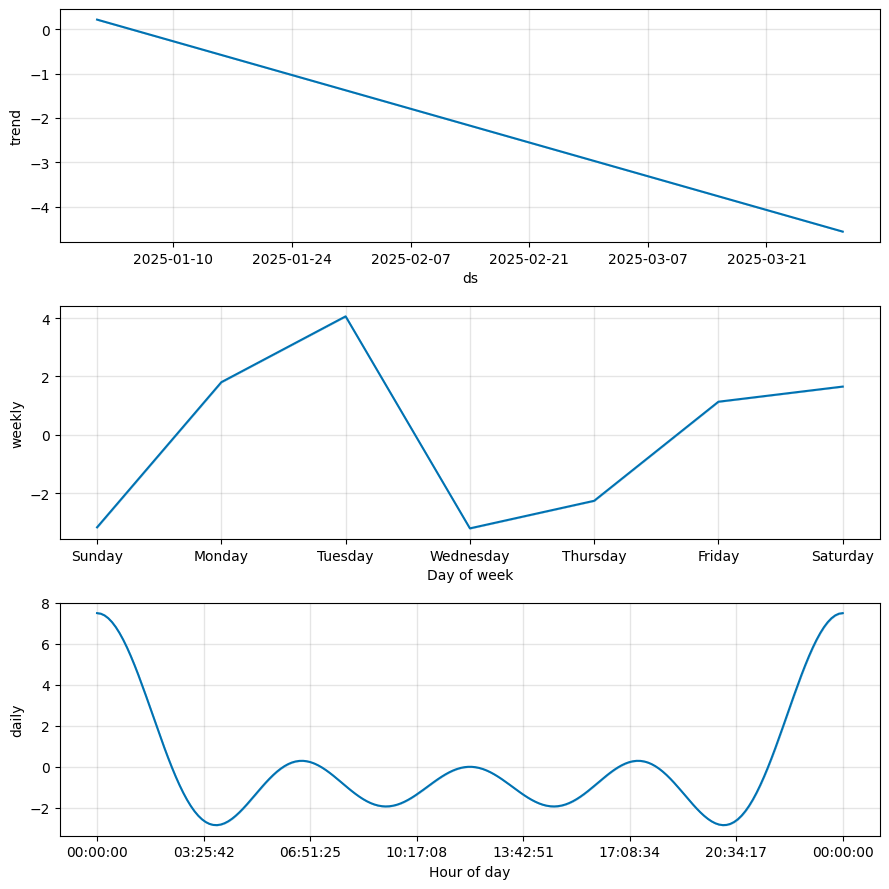

In [7]:
fig2 = model.plot_components(forecast)
plt.show()


In [8]:
forecast_out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]
forecast_out.to_csv("../data/processed/forecast_" + sku_focus + ".csv", index=False)


In [ ]:
print(f"✅ Forecast generated and saved for {sku_focus}")

✅ Forecast generated and saved for SKU0001


: 